<center> <h1> Zomato Business Insights </h1> </center>

## 1. Data Cleaning + Feature Engineering:

In [1]:
import pandas as pd
import numpy as np
import re
import ast
from datetime import datetime

#Ignore all imcoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('zomato_dataset.csv', encoding='utf-8')

print("Original Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# 1. Basic Cleaning
# Rename columns for easier use
df.columns = [col.strip().lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_') for col in df.columns]

# Drop duplicates if any
df = df.drop_duplicates(subset=['url', 'name'])

# 2. Handle Rate Column
def clean_rate(x):
    if pd.isna(x) or x == 'NEW' or x == '-':
        return np.nan
    # Remove /5 and convert to float
    return float(str(x).replace('/5', '').strip())

df['rate'] = df['rate'].apply(clean_rate)

# 3. Clean approx_cost
def clean_cost(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace('₹', '').replace(',', '').strip()
    try:
        return float(x)
    except:
        return np.nan

df['approx_cost_for_two_people'] = df['approx_costfor_two_people'].apply(clean_cost)

# 4. Handle Boolean Columns
df['online_order'] = df['online_order'].map({'Yes': True, 'No': False})
df['book_table'] = df['book_table'].map({'Yes': True, 'No': False})

# 5. Clean Location and City
df['location'] = df['location'].str.strip()
df['listed_in_city'] = df['listed_incity'].str.strip()

# 6. Clean Cuisines and Rest Type
df['cuisines'] = df['cuisines'].fillna('Unknown').str.strip()
df['rest_type'] = df['rest_type'].fillna('Unknown').str.strip()

# Split cuisines into list
df['cuisines_list'] = df['cuisines'].str.split(', ')

# 7. Handle Reviews List (Parse as list of tuples)
def safe_parse_reviews(x):
    if pd.isna(x) or x == '[]':
        return []
    try:
        # Fix common encoding issues in reviews
        x = str(x).replace('Ã\x83Ã\x82', "'").replace('Ã¢\x80\x99', "'")
        return ast.literal_eval(x) if isinstance(x, str) else x
    except:
        return []

df['reviews_list_parsed'] = df['reviews_list'].apply(safe_parse_reviews)

# Extract average rating from reviews if needed
def extract_review_ratings(reviews):
    ratings = []
    for rev in reviews:
        if isinstance(rev, (list, tuple)) and len(rev) > 0:
            match = re.search(r'Rated (\d+\.\d+)', str(rev[0]))
            if match:
                ratings.append(float(match.group(1)))
    return np.mean(ratings) if ratings else np.nan

df['avg_review_rating'] = df['reviews_list_parsed'].apply(extract_review_ratings)

# 8. Clean Dish Liked
df['dish_liked'] = df['dish_liked'].fillna('Unknown').str.strip()
df['dish_liked_list'] = df['dish_liked'].str.split(', ')

# 9. Votes (already numeric)
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# 10. Final DataFrame Info
print("\nAfter Cleaning Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# 11. Remove invalid URLs:
df['url'] = df['url'].astype(str).str.strip()
df = df[df['url'].str.startswith('https://', na=False)]
df = df[~df['url'].str.contains('RATED|rated|!|cooked|ordered|experience', case=False, na=False)]

# 12. IMPUTATION - FILL ALL MISSING VALUES:

print("Missing Values BEFORE Imputation:\n", df.isnull().sum())

# Convert list columns to string (to avoid errors)
list_cols = ['cuisines_list', 'dish_liked_list', 'reviews_list_parsed']
for col in list_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Numerical Imputation (Median)
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical Imputation (Most Frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])





# Save cleaned dataset
df.to_csv('final_zomato_cleaned_dataset.csv', index=False)
print("\nCleaned dataset saved as 'final_zomato_cleaned_dataset.csv'")

# For EDA Quick Stats
print("\nQuick Stats:")
print(df.describe())

Original Shape: (51717, 17)

Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

After Cleaning Shape: (51717, 23)

Missing Values:
 url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                          10052
votes                             0
phone                          1208
location                         21
rest_type                         0
dish_liked                        0
cuisines                          0
approx_costfor_two_people       346
reviews_list                      0
menu_item                         0
listed_intype                     0
listed_incity                     0
approx_cost_for_two_people      346
listed_in_city               

## 2. EDA and Business Insights:

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51715 entries, 0 to 51716
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         51715 non-null  object 
 1   address                     51715 non-null  object 
 2   name                        51715 non-null  object 
 3   online_order                51715 non-null  bool   
 4   book_table                  51715 non-null  bool   
 5   rate                        51715 non-null  float64
 6   votes                       51715 non-null  float64
 7   phone                       51715 non-null  object 
 8   location                    51715 non-null  object 
 9   rest_type                   51715 non-null  object 
 10  dish_liked                  51715 non-null  object 
 11  cuisines                    51715 non-null  object 
 12  approx_costfor_two_people   51715 non-null  object 
 13  reviews_list                51715 no

In [3]:
#Frequency of orders placed online and the ones placed offline:
df["online_order"].value_counts().reset_index(name="Frequency")

,online_order,Frequency
0,True,30444
1,False,21271


In [4]:
#Frequency of people who booked a table and who didnt:
df["book_table"].value_counts().reset_index(name="Frequency")

,book_table,Frequency
0,False,45266
1,True,6449


In [5]:
#Top - 5 locations having most of the restuarants:
df["location"].value_counts().head(5).reset_index()

,location,count
0,BTM,5145
1,HSR,2523
2,Koramangala 5th Block,2504
3,JP Nagar,2235
4,Whitefield,2144


In [6]:
#Top-5 restaurant types:
df["rest_type"].value_counts().head(5).reset_index()

,rest_type,count
0,Quick Bites,19132
1,Casual Dining,10330
2,Cafe,3732
3,Delivery,2602
4,Dessert Parlor,2263


In [7]:
#Top-5 Dining Options:
df["listed_intype"].value_counts().head(5).reset_index()

,listed_intype,count
0,Delivery,25940
1,Dine-out,17779
2,Desserts,3593
3,Cafes,1723
4,Drinks & nightlife,1101


In [8]:
#Cost of dining in the top-5 restaurants:
df["approx_cost_for_one_person"] = df["approx_cost_for_two_people"]/2
df.groupby("rest_type")["approx_cost_for_one_person"].mean().head(5).reset_index()

,rest_type,approx_cost_for_one_person
0,Bakery,185.157756
1,"Bakery, Beverage Shop",89.062500
2,"Bakery, Cafe",314.423077
3,"Bakery, Dessert Parlor",178.571429
4,"Bakery, Food Court",250.000000


In [9]:
#Cost Analysis by Restaurant Type:
df.groupby('rest_type')['approx_cost_for_two_people'].agg(['mean', 'median', 'count']).round(2)

,mean,median,count
rest_type,,,
Bakery,370.32,400.0,1141
"Bakery, Beverage Shop",178.12,200.0,16
"Bakery, Cafe",628.85,600.0,78
"Bakery, Dessert Parlor",357.14,350.0,147
"Bakery, Food Court",500.00,500.0,2
...,...,...,...
"Sweet Shop, Dessert Parlor",100.00,100.0,1
"Sweet Shop, Quick Bites",260.11,200.0,178
Takeaway,296.25,275.0,120


In [10]:
#Most popular cusines:
df_exploded = df.explode('cuisines_list').copy()

df_exploded['cuisines_list'] = (df_exploded['cuisines_list']
                                .astype(str)
                                .str.strip()
                                .str.replace(r"[\[\]']", "", regex=True)
                                .str.strip())

popular_cuisines = df_exploded['cuisines_list'].value_counts().head(15)

print("=== Top 15 Most Popular Cuisines ===")
popular_cuisines.reset_index()

=== Top 15 Most Popular Cuisines ===


,cuisines_list,count
0,North Indian,2913
1,"North Indian, Chinese",2385
2,South Indian,1828
3,Biryani,918
4,"Bakery, Desserts",911
5,Fast Food,803
6,Desserts,766
7,Cafe,756
8,"South Indian, North Indian, Chinese",726
9,Bakery,651


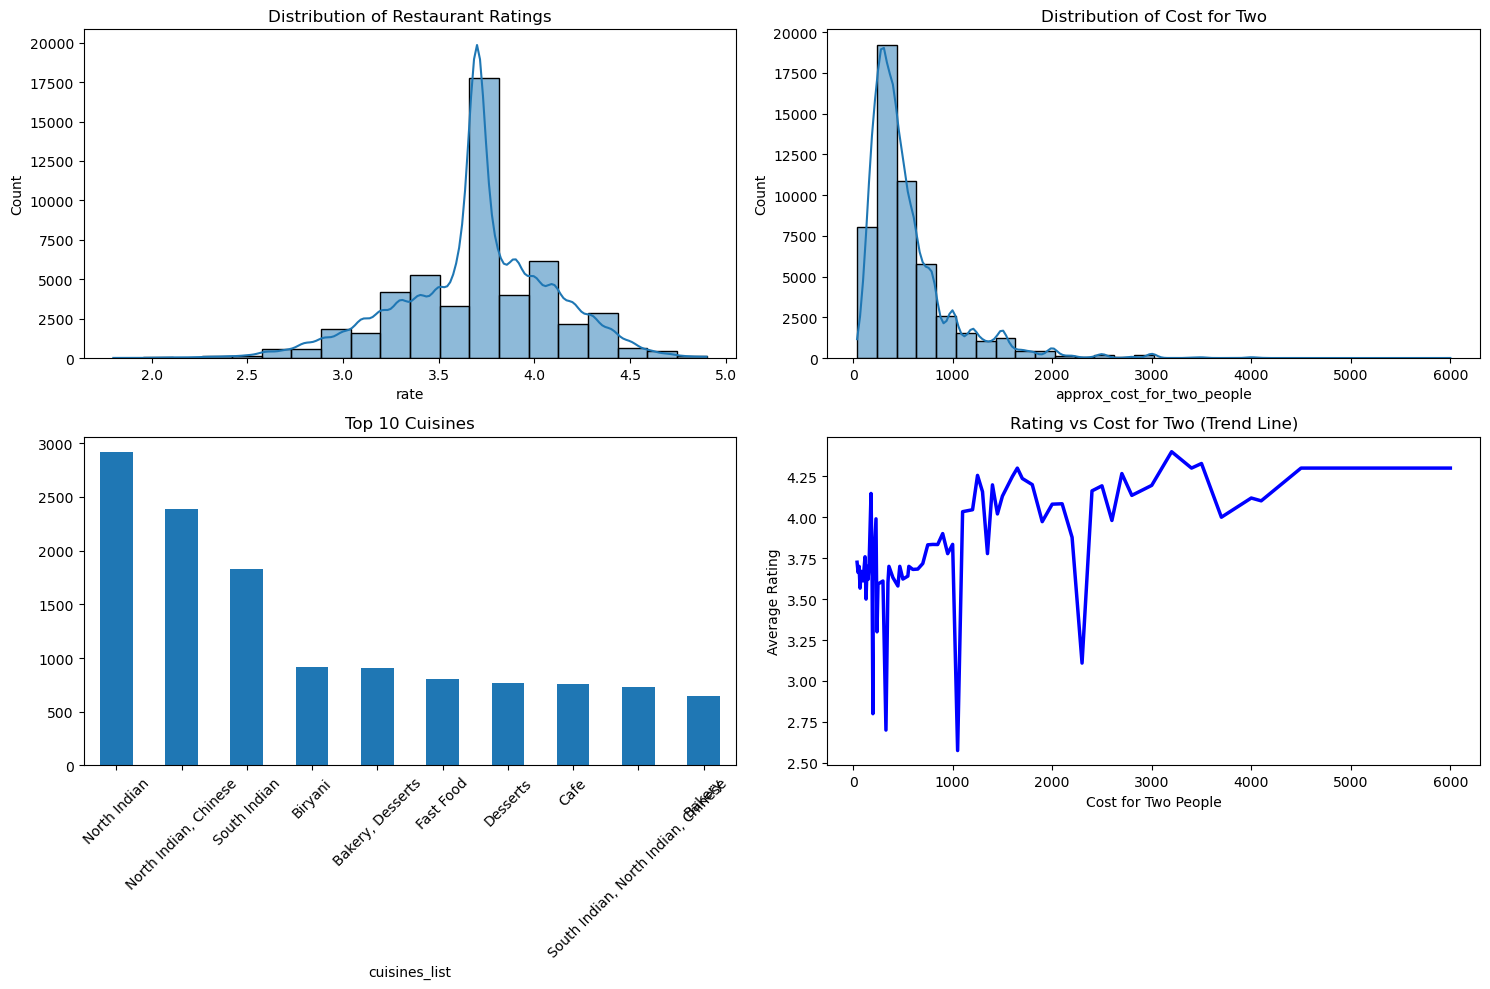

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

popular_cuisines = df_exploded['cuisines_list'].value_counts().head(15)

# 1. Rating Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['rate'].dropna(), bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')

# 2. Cost Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['approx_cost_for_two_people'].dropna(), bins=30, kde=True)
plt.title('Distribution of Cost for Two')

# 3. Top 10 Cuisines
plt.subplot(2, 2, 3)
popular_cuisines.head(10).plot(kind='bar')
plt.title('Top 10 Cuisines')
plt.xticks(rotation=45)

# 4. Rating vs Cost
plt.subplot(2, 2, 4)
sns.lineplot(data=df, x='approx_cost_for_two_people', y='rate', 
             estimator='mean', ci=None, linewidth=2.5, color='blue')
plt.title('Rating vs Cost for Two (Trend Line)')
plt.xlabel('Cost for Two People')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

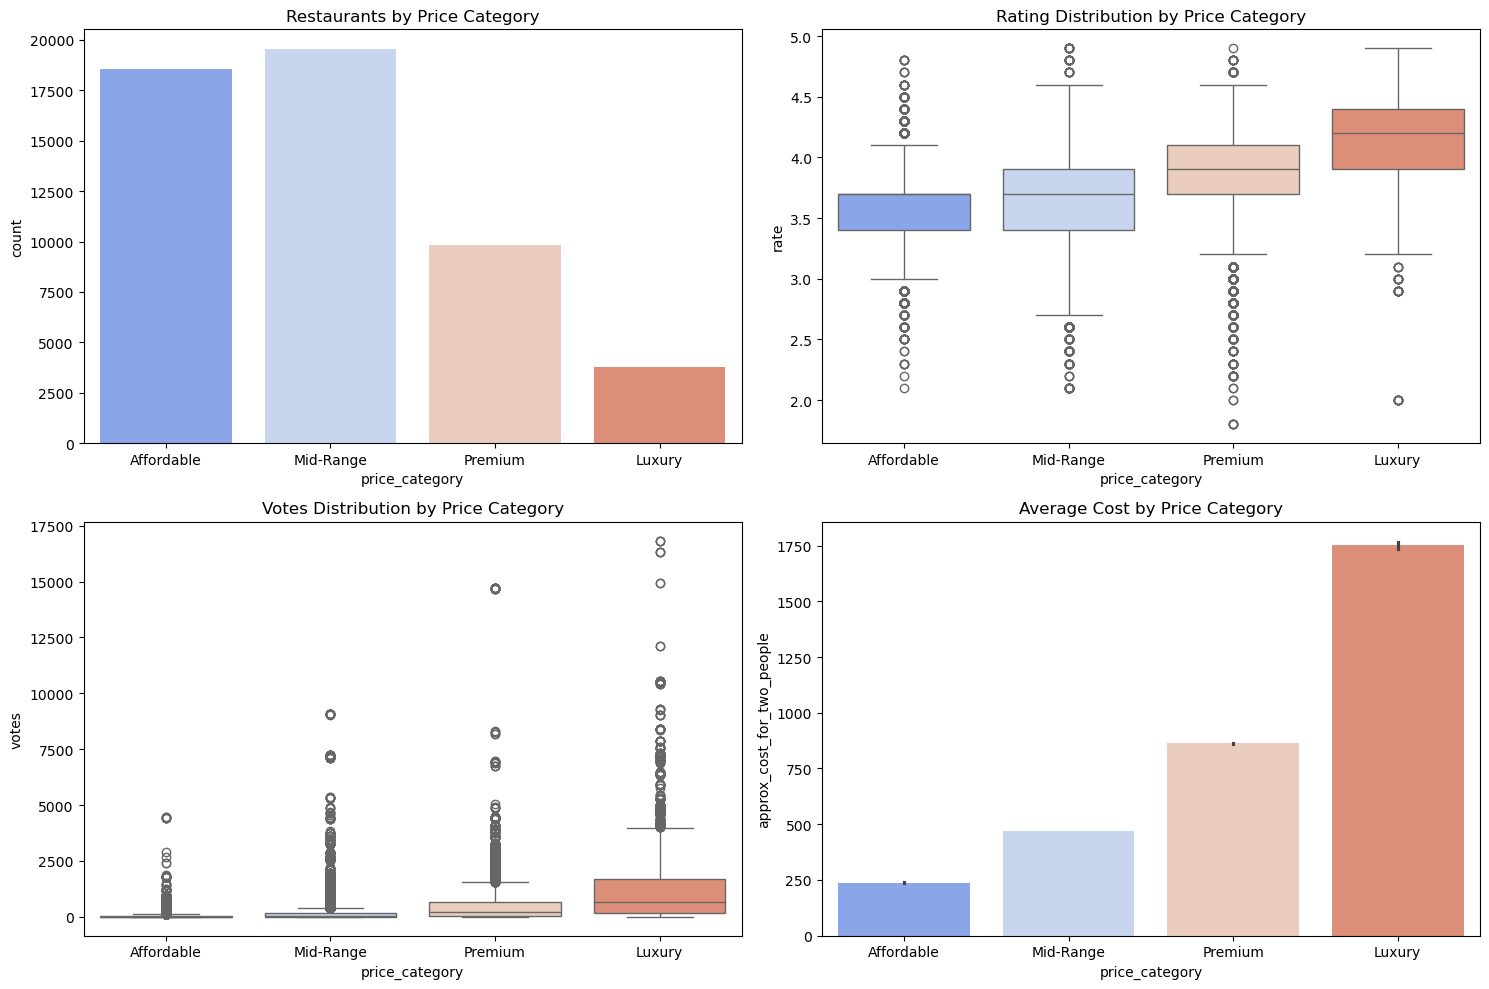

In [12]:
# Price Range Categories
df['price_category'] = pd.cut(df['approx_cost_for_two_people'],
                              bins=[0, 300, 600, 1200, 5000],
                              labels=['Affordable', 'Mid-Range', 'Premium', 'Luxury'])

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='price_category', palette='coolwarm')
plt.title('Restaurants by Price Category')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='price_category', y='rate', palette='coolwarm')
plt.title('Rating Distribution by Price Category')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='price_category', y='votes', palette='coolwarm')
plt.title('Votes Distribution by Price Category')

plt.subplot(2, 2, 4)
sns.barplot(data=df, x='price_category', y='approx_cost_for_two_people', estimator='mean', palette='coolwarm')
plt.title('Average Cost by Price Category')

plt.tight_layout()
plt.show()

# Conclusion & Project Summary

##  Zomato Business Insights - End-to-End Analysis

### 1. Project Objective
This project performs a comprehensive analysis of the Zomato restaurant dataset to extract meaningful business insights.
---

### 2. Data Cleaning & Preprocessing

- **Loaded** raw Zomato dataset (`zomato_dataset.csv`)
- **Renamed columns** for better readability
- **Handled missing values** using Median (numerical) and Most Frequent (categorical) imputation
- **Cleaned key columns**:
  - `rate`: Removed `/5` and handled 'NEW' / '-' values
  - `approx_cost_for_two_people`: Removed currency symbols and commas
  - Converted boolean columns (`online_order`, `book_table`)
- **Feature Engineering**:
  - Created `approx_cost_for_one_person`
  - Split `cuisines` into `cuisines_list`
  - Parsed `reviews_list` and extracted `avg_review_rating`
  - Removed invalid/garbage URLs
- **Saved** final cleaned dataset as `final_zomato_cleaned_dataset.csv`

**Final Dataset Shape**: 51,715 rows × 23 columns

---

### 3. Exploratory Data Analysis (EDA) & Business Insights

#### Key Findings:

- **Online Orders**: ~59% restaurants accept online orders
- **Table Booking**: Only ~12.5% restaurants allow table booking
- **Top Locations**: BTM, HSR, Koramangala 5th Block, JP Nagar, Whitefield
- **Top Restaurant Types**: Quick Bites, Casual Dining, Cafe
- **Most Popular Cuisines**: North Indian, Chinese, South Indian, Biryani, Desserts
- **Price vs Rating**: Higher cost restaurants generally have better ratings
- **Price Categories**: Most restaurants fall in **Mid-Range** (₹300–600)

#### Visual Insights:
- Distribution plots for Rating, Cost, and Votes
- Relationship between Cost and Rating (with regression line)
- Impact of Online Order & Table Booking on ratings
- Price category analysis using boxplots and bar charts
- Top 10 locations and cuisines visualized



### 5. Business Recommendations

1. **Focus on Mid-Range Pricing**: Most profitable segment with good volume and ratings.
2. **Online Ordering**: Strongly recommended — correlates with higher customer reach.
3. **Location Strategy**: Prioritize BTM, Koramangala, HSR, and Whitefield.
4. **Cuisine Mix**: North Indian + Chinese combination performs very well.
5. **Quality over Quantity**: Higher-rated restaurants can charge premium pricing.


**Project Completed Successfully** 

**Author**: Om Satyawan Pathak
**Date**: 25 May 2026

---